In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sonjorahmed/ecommerce-customer-features/ecommerce_customer_features.csv


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import(
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

In [41]:
df= pd.read_csv("/kaggle/input/datasets/sonjorahmed/ecommerce-customer-features/ecommerce_customer_features.csv")
display(df.head(4))
df.info()


,customer_id,signup_timestamp,age,annual_income,spending_score,membership_tier,preferred_category,device_type,last_purchase_amount,discount_usage_pct,customer_feedback
0,CUST-1001,2023-01-14 09:30:00,28,52000.0,65,Bronze,Electronics,Mobile,120.5,15.0,Great gadget selection fast delivery
1,CUST-1002,2022-11-05 18:45:00,45,98000.0,82,Gold,Fashion,Desktop,450.0,5.0,Loved the winter collection quality
2,CUST-1003,2023-03-22 14:15:00,34,67000.0,45,Silver,Home,Mobile,85.2,25.0,Items arrived on time as expected
3,CUST-1004,2021-08-19 21:10:00,52,145000.0,91,Platinum,Electronics,Desktop,1250.0,0.0,Premium flagship laptop is superb


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           40 non-null     object 
 1   signup_timestamp      40 non-null     object 
 2   age                   40 non-null     int64  
 3   annual_income         40 non-null     float64
 4   spending_score        40 non-null     int64  
 5   membership_tier       40 non-null     object 
 6   preferred_category    40 non-null     object 
 7   device_type           40 non-null     object 
 8   last_purchase_amount  40 non-null     float64
 9   discount_usage_pct    40 non-null     float64
 10  customer_feedback     40 non-null     object 
dtypes: float64(3), int64(2), object(6)
memory usage: 3.6+ KB


In [42]:
std_scaler= StandardScaler()
minmax_scaler= MinMaxScaler()
rob_scaler= RobustScaler()

In [43]:
numer_clos= ["age", "annual_income", "last_purchase_amount"]
df_num= df[numer_clos].copy()
df_num.head(4)

,age,annual_income,last_purchase_amount
0,28,52000.0,120.5
1,45,98000.0,450.0
2,34,67000.0,85.2
3,52,145000.0,1250.0


# Standard Scaling

In [44]:
df_std= pd.DataFrame(std_scaler.fit_transform(df_num), columns=[f"{c}_std_" for c in numer_clos])

In [45]:
df_std.head()

,age_std_,annual_income_std_,last_purchase_amount_std_
0,-0.875093,-0.833778,-0.610725
1,0.583396,0.212710,-0.143859
2,-0.360333,-0.492532,-0.660741
3,1.183950,1.281948,0.989655
4,-1.304061,-1.311523,-0.721951


# MinMax Scaling

In [46]:
df_minmax= pd.DataFrame(minmax_scaler.fit_transform(df_num), columns=[f"{c}_minmax_" for c in numer_clos])

In [47]:
df_minmax.head()

,age_minmax_,annual_income_minmax_,last_purchase_amount_minmax_
0,0.175,0.16875,0.032671
1,0.600,0.45625,0.151625
2,0.325,0.26250,0.019928
3,0.775,0.75000,0.440433
4,0.050,0.03750,0.004332


# Robust Scaling

In [48]:
df_robust= pd.DataFrame(rob_scaler.fit_transform(df_num), columns=[f"{c}_robust_" for c in numer_clos])
df_robust.head()

,age_robust_,annual_income_robust_,last_purchase_amount_robust_
0,-0.441558,-0.489960,-0.140034
1,0.441558,0.248996,0.420102
2,-0.129870,-0.248996,-0.200042
3,0.805195,1.004016,1.780068
4,-0.701299,-0.827309,-0.273481


# Combine this All Three (3) Methods :

In [49]:
df.shape

(40, 11)

In [50]:
pd.DataFrame(df.columns)

,0
0,customer_id
1,signup_timestamp
2,age
3,annual_income
4,spending_score
5,membership_tier
6,preferred_category
7,device_type
8,last_purchase_amount
9,discount_usage_pct


In [51]:
comparison_df= pd.concat([
    df_num[["last_purchase_amount"]].rename(columns={"last_purchase_amount": "Original ($)"}),
    df_std[["last_purchase_amount_std_"]].rename(columns={"last_purchase_amount_std_": "Standard Scaler"}),
    df_minmax[["last_purchase_amount_minmax_"]].rename(columns={"last_purchase_amount_minmax_": "MinMax Scaler"}),
    df_robust[["last_purchase_amount_robust_"]].rename(columns={"last_purchase_amount_robust_": "Robust Scaler"})
], axis=1)
display(comparison_df.head())

,Original ($),Standard Scaler,MinMax Scaler,Robust Scaler
0,120.5,-0.610725,0.032671,-0.140034
1,450.0,-0.143859,0.151625,0.420102
2,85.2,-0.660741,0.019928,-0.200042
3,1250.0,0.989655,0.440433,1.780068
4,42.0,-0.721951,0.004332,-0.273481


In [52]:
print("Original Dataset Columns \n")
pd.DataFrame(df.columns)

Original Dataset Columns 



,0
0,customer_id
1,signup_timestamp
2,age
3,annual_income
4,spending_score
5,membership_tier
6,preferred_category
7,device_type
8,last_purchase_amount
9,discount_usage_pct


In [53]:
comparison_df.shape

(40, 4)

In [54]:
print("New Created Columns: \n")
pd.DataFrame(comparison_df.columns)

New Created Columns: 



,0
0,Original ($)
1,Standard Scaler
2,MinMax Scaler
3,Robust Scaler


# Visualization of this 3 Methods : 

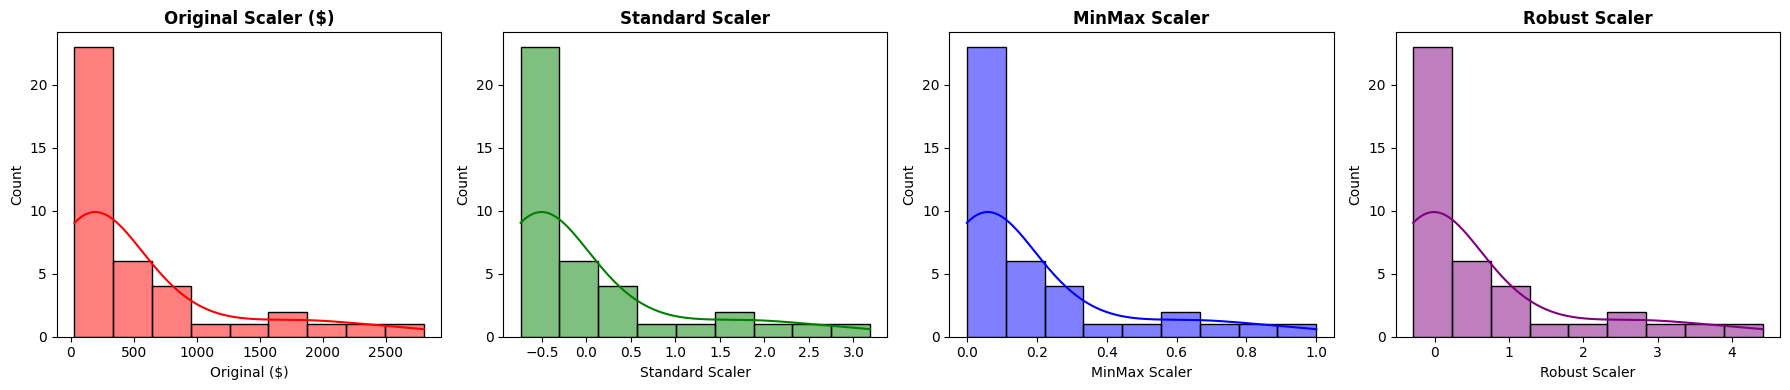

In [55]:
import seaborn as sns

fig, axes= plt.subplots(1,4, figsize=(18,4))

sns.histplot(comparison_df["Original ($)"], kde= True, ax= axes[0], color="red")
axes[0].set_title("Original Scaler ($)", fontweight="bold")

sns.histplot(comparison_df["Standard Scaler"], kde= True, ax= axes[1], color="green")
axes[1].set_title("Standard Scaler", fontweight="bold")

sns.histplot(comparison_df["MinMax Scaler"], kde= True, ax= axes[2], color="blue")
axes[2].set_title("MinMax Scaler", fontweight="bold")

sns.histplot(comparison_df["Robust Scaler"], kde= True, ax= axes[3], color="purple")
axes[3].set_title("Robust Scaler", fontweight="bold")


plt.tight_layout()
plt.show()